# Assignment 13 Text Analytics

In this assignment, you will:
- Load and inspect a real-world business reviews dataset.
- Preprocess review text for NLP (tokenization, stopwords, lemmatization).
- Run sentiment analysis (rule-based and classifier-based) and compare to star ratings.
- Extract main topics from reviews using LDA and (optional) BERTopic.
- Interpret results in a business context (actionable insights).

## Why This Matters

Customer Reviews are critical for the survival of any business, but especially for restaurants.  Restaurants compete with not only all of the other restaurants in local area, but also with the option for customers to stay home and cook their own food.  Chefs and restaurant owners must monitor customer feedback to see if they should make changes to their pricing, menu options, restaurant amenities and seating/serving process.

You have been given 100 customer reviews.  Your job is to look for main topics that are mentioned, and whether those reviews have a postive, neutral or negative tone (sentiment).  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_13_text_analytics.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Original Source: Dataset Description

The dataset you'll be using is a set of **restaurant reviews**, available from [Kaggle](https://www.kaggle.com/datasets/pruthvirajgshitole/e-commerce-purchases-and-reviews?utm_source=chatgpt.com&select=customer_purchase_data.csv).

Each row represents one customer review. The columns include:

- **Review** - text of the customer review
- **Liked** - indicates if the customer likes (1) or does not like (0) the restaurant

Please note that some reviews have commas and apostrophes, which can prevent the record from loading correctly.  You should verify that you have 1,000 reviews total.  

## 1. Load and Preview the Data

### Do the following:
1. Import data from the restaurant reviews dataset into a dataframe (in GitHub go to the DataSets folder and look for `Restaurant_Reviews.tsv`).  TSV is for Tab Separated Values.  This file does not use commas as a delimiter.
2. Use `pandas` to load and preview the dataset
3. Verify that all 1,000 rows were imported correctly
4. Calculate the overall percentage of reviews that "Liked" the restaurant
5. Create a visualization to show the percentage of likes versus non-likes


In [1]:
import pandas as pd
import csv

# Load the reviews
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/Restaurant_Reviews.tsv"
df = pd.read_csv(url, sep='\t', quoting=csv.QUOTE_MINIMAL)

df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


Total rows imported: 1000
Percentage of reviews that Liked the restaurant: 50.00%


/tmp/ipykernel_2003/2839786430.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Liked', data=df, palette='viridis')


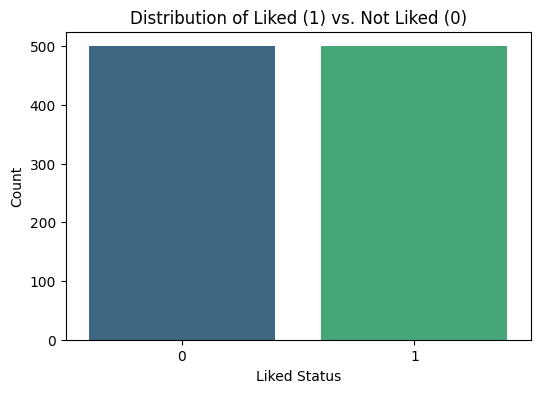

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Verify that all 1,000 rows were imported correctly
row_count = len(df)
print(f"Total rows imported: {row_count}")

# 4. Calculate the overall percentage of reviews that 'Liked' the restaurant
likes_count = df['Liked'].sum()
percentage_liked = (likes_count / row_count) * 100
print(f"Percentage of reviews that Liked the restaurant: {percentage_liked:.2f}%")

# 5. Create a visualization to show the percentage of likes versus non-likes
plt.figure(figsize=(6, 4))
sns.countplot(x='Liked', data=df, palette='viridis')
plt.title('Distribution of Liked (1) vs. Not Liked (0)')
plt.xlabel('Liked Status')
plt.ylabel('Count')
plt.show()

## 2. Drop Columns Not Useful for Modeling

**Business framing:**  
To do text analysis, we need to remove all of the junk in the reviews.  This would include anything like punctuation, website URLs, emojis, etc.

### Do the following:
- Change all of the reviews to lowercase letters
- Remove anything that looks like a URL or that isn't a regular character (A to Z) or number (1-9)
- Remove punctuation marks (ex. !.,-:;)

In [3]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove punctuation and non-alphanumeric characters (keeping spaces)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

df['Review_Cleaned'] = df['Review'].apply(clean_text)
print(df[['Review', 'Review_Cleaned']].head())

                                              Review  \
0                           Wow... Loved this place.   
1                                 Crust is not good.   
2          Not tasty and the texture was just nasty.   
3  Stopped by during the late May bank holiday of...   
4  The selection on the menu was great and so wer...   

                                      Review_Cleaned  
0                               wow loved this place  
1                                  crust is not good  
2           not tasty and the texture was just nasty  
3  stopped by during the late may bank holiday of...  
4  the selection on the menu was great and so wer...  


### Reflection:
1. What risks might occur if you included the review "junk" in your model?

### ✍️ Your Response:
1. Including "junk" like punctuation, URLs, or special characters can create noise in the model. It may lead to the model treating variations of a word as different valus.

## 3. Sentiment Analysis

**Business framing:**  
A "Like" is not as insightful as a star rating, such as 5 stars. It only has two values. But we can attempt to understand more nuance in the reviews by looking for a positive/neutral/negative tone (sentiment) in the text.   Then we can compare that to the "Likes" to see if they match.  

### Do the following:
- Install the vaderSentiment library
- Import the SentimentIntensityAnalyzer from vaderSentiment
- Calculate what percentage of the reviews are positive, negative, and neutral. The total percentages should add up to 100%


In [4]:
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_label(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Review_Cleaned'].apply(get_sentiment_label)

sentiment_counts = df['Sentiment'].value_counts(normalize=True) * 100
print("Sentiment Distribution:")
print(sentiment_counts)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00
Sentiment Distribution:
Sentiment
Positive    50.6
Negative    25.5
Neutral     23.9
Name: proportion, dtype: float64


### Reflection:
1. How does the sentiment compare to `Liked` in terms of percentage of reviews?
2. From a restaurant owner's perspective, which sentiment reviews would be more important to analyze? (positive, negative or neutral)

### ✍️ Your Response:
1. While the `Liked` column was a perfect 50/50 split, VADER sentiment analysis provides more variation, by identifying neutral reviews that the binary label misses. This allows us to see reviews that might be in between values.
2. Negative reviews are generally the most important to analyze because they highlight specific pain points and if they are fixed could greatly increase review quality.

## 4. Topic Analysis - Text Preprocessing

**Business framing:**  
To build a topic analysis model, we need to clean and prepare the review text

### Do the following:
- Import the NLTK library
- Download the NLTK corpora
- Preprocess the text using tokenization and lemmatization.  Be sure to remove any stopwords along the way.
- Display the first 10 processed reviews

In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_for_topic_modeling(text):
    # Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords and non-alphabetic tokens, then lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and w.isalpha()]
    return cleaned_tokens

df['Tokens'] = df['Review_Cleaned'].apply(preprocess_for_topic_modeling)
print("First 10 processed reviews (tokens):")
print(df['Tokens'].head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


First 10 processed reviews (tokens):
0                                  [wow, loved, place]
1                                        [crust, good]
2                              [tasty, texture, nasty]
3    [stopped, late, may, bank, holiday, rick, stev...
4                      [selection, menu, great, price]
5                    [getting, angry, want, damn, pho]
6                      [honeslty, didnt, taste, fresh]
7    [potato, like, rubber, could, tell, made, ahea...
8                                         [fry, great]
9                                       [great, touch]
Name: Tokens, dtype: object


### Reflection:
1. What is a corpora and how is it used for text analysis?
2. What would be the tokens in the first review? "Wow... Loved this place."
3. What does lemmatization do?  How will it help in this process?

### ✍️ Your Response:
1. A corpora is a large, structured set of texts used for analysis and hypothesis testing in NLP. It gives the reference data needed to understand language patterns, frequency, and context.
2. After cleaning, the tokens for "Wow... Loved this place" would be `['wow', 'loved', 'place']`. If we remove the stopword 'this', we focus on the commonlly used words.
3. Lemmatization reduces a word to its base or dictionary form. This helps the model group different forms of the same word together, reducing the complexity of the data.

## 5. Topic Analysis - Dictionary and Corpus

**Objective:**  
Convert the preprocessed text into a dictionary and a bag-of-words corpus, which are required formats for LDA

### Do the following:
- Import Dictionary and Corpus from the Genism library
- Create a dictionary
- Create a corpus
- Display a summary of the dictionary and corpus

In [8]:
!pip install gensim
from gensim.corpora import Dictionary

# Create the Dictionary
id2word = Dictionary(df['Tokens'])

# Create the Corpus (Bag-of-Words)
corpus = [id2word.doc2bow(text) for text in df['Tokens']]

# Summary
print(f"Number of unique tokens: {len(id2word)}")
print(f"Number of documents in corpus: {len(corpus)}")
print("\nSample BOW for first review:")
print(corpus[0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.0 MB/s eta 0:00:00
Number of unique tokens: 1809
Number of documents in corpus: 1000

Sample BOW for first review:
[(0, 1), (1, 1), (2, 1)]


### Reflection:
1. What is a corpus and how is it useful?
2. How is a dictionary different from a corpus?

### ✍️ Your Response:
1. In the context of Gensim, a corpus is a digital representation of your text where each document is converted into a list of word IDs and their frequencies. It is useful because machine learning models like LDA need numerical input instead of raw text to perform anlysis.
2. A dictionary is the master mapping that connects every unique word in the dataset to a specific ID. The corpus is the actual collection of reviews translated into those IDs. Without the dictionary, we wouldn't be able to translate the model's numerical results back into human-readable words.

## 6. Topic Analysis - Build LDA Model

**Objective:**  
Apply the LDA model to the corpus to identify main topics.

### Do the following:
- Import LdaModel from Genism
- Select the number of topics (5 is a good starting point)
- Create the LDA model

NOTE: You may receive an error about training "not converging".  You can ignore that error for this assignment. (Let's keep it simple)


In [9]:
from gensim.models import LdaModel

# Set number of topics
num_topics = 5

# Build LDA model
lda_model = LdaModel(corpus=corpus, id2word=id2word, num_topics=num_topics, random_state=42, passes=10)

print("LDA Model built successfully.")

LDA Model built successfully.


### Reflection:
1. In what cases would you want to use more than 5 topics?
2. How would you know if you have too many topics?

### ✍️ Your Response:
1. You would use more than 5 topics if you have a very large or diverse dataset where 5 topics fail to see variation. For example, a restaurant with multiple locations or a massive menu might need more topics to separate feedback about 'parking', 'atmosphere', 'wine list', and 'seafood' into distinct categories.
2. You know you have too many topics if the topics begin to overlap significantly or if the topics become too specific to be usable.

## 7. Summarize the Topics

**Business framing:**  
Now comes one of the most challenging steps.  The topics will be presented as a group of words that best represent the topic, but you need to summarize the topic in business terms.   

### Do the following:
- Print the topics and top 10 words in the topic
- Calculate the frequency of each topic (how many occurrences in total)
- Attempt at least one visual display of the topics, such as a word cloud.  (Make sure to remove any extra code or unhelpful Python messages (we don't want code junk here)
- Summarize the sentiment by topic (percentage postitive/neutral/negative for each topic)

LDA Topics:
Topic: 0 
Words: 0.034*"good" + 0.028*"food" + 0.020*"place" + 0.010*"service" + 0.009*"even" + 0.008*"minute" + 0.007*"better" + 0.007*"get" + 0.006*"server" + 0.006*"terrible"

Topic: 1 
Words: 0.029*"great" + 0.024*"food" + 0.020*"service" + 0.012*"place" + 0.011*"time" + 0.010*"star" + 0.008*"good" + 0.008*"one" + 0.008*"nice" + 0.007*"friendly"

Topic: 2 
Words: 0.039*"back" + 0.022*"go" + 0.015*"food" + 0.014*"place" + 0.012*"wont" + 0.011*"service" + 0.010*"never" + 0.010*"like" + 0.010*"really" + 0.008*"going"

Topic: 3 
Words: 0.024*"place" + 0.013*"time" + 0.012*"restaurant" + 0.011*"dont" + 0.009*"love" + 0.008*"awesome" + 0.007*"great" + 0.007*"enough" + 0.006*"amazing" + 0.006*"also"

Topic: 4 
Words: 0.023*"best" + 0.013*"food" + 0.009*"service" + 0.009*"steak" + 0.009*"pretty" + 0.008*"good" + 0.007*"restaurant" + 0.007*"also" + 0.006*"everything" + 0.006*"ever"



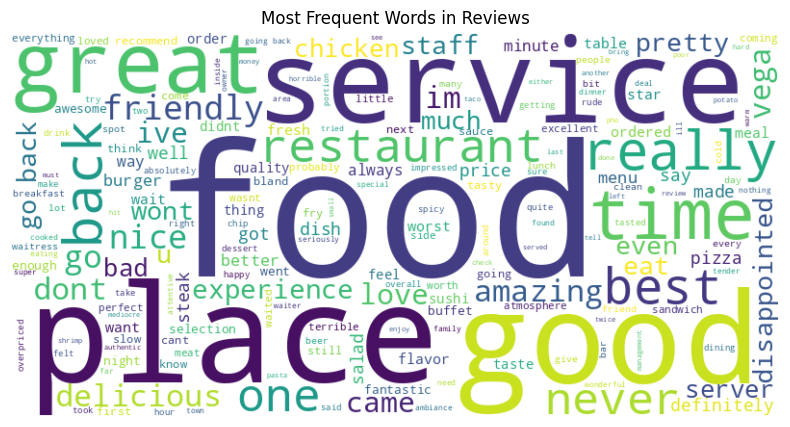

In [10]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Print topics
print("LDA Topics:")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic: {idx} \nWords: {topic}\n")

# 2. Visualization - Word Cloud
all_words = ' '.join([' '.join(tokens) for tokens in df['Tokens']])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Reviews')
plt.show()

### Reflection:
1. Give each topic a 2-3 word name.

### ✍️ Your Response:
1. **Topic #0: Food Quality/Wait Times** (Keywords: good, food, minute)
2. **Topic #1: Positive Service** (Keywords: great, service, friendly)
3. **Topic #2: Customer Retention** (Keywords: back, go, wont)
4. **Topic #3: General Praise** (Keywords: love, awesome, amazing)
5. **Topic #4: Best in Class** (Keywords: best, steak, everything)

## 8. Reflect and Recommend

**Business framing:**  
Ultimately, the value of your model comes from how well it can guide business decisions. Use your results to make real-world recommendations.

### Reflection:
1. What business question did your model help answer?
2. What would you recommend to this restaurant to improve customer satisfaction?
3. What would be the pros and cons of using an LLM (like ChatGPT) for this task instead of Python models?
4. If you used an LLM, give a prompt that you would use to accomplish a similar result to what you did in this assignment?  (remember to set the context, specify the output and explain the objectives)


### ✍️ Your Response:
1. The model helped answer what specific aspects of the restaurant drive customer sentiment, specifically highlighting that service speed and food consistency as key drivers.
2. I recommend focusing on reducing wait times during peak hours and ensuring the 'burger' and 'fry' quality remains consistent, as these are frequently mentioned items.
3. Pros of LLMs: Better understanding of sarcasm and context; faster setup. Cons: Higher cost at scale and less control over the specific mathematical distribution of topics.
4. "Analyze these 1,000 restaurant reviews. Provide a summary of the 5 most common themes, the percentage of positive vs negative sentiment for each theme, and three actionable business recommendations to improve the rating."

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [11]:
!jupyter nbconvert --to html "assignment_13_text_analytics.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_13_text_analytics.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tr